--- RAW DATA OVERVIEW ---
Shape: (891, 12)
Total Missing Values initially: 866

Missing values per column:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- POST-PROCESSING OVERVIEW ---
Final Shape: (891, 14)
Total Missing Values Remaining: 0
Missing Values Reduction: 100.0%
Saved preprocessed dataset to 'cleaned_data_processed.csv'


/tmp/ipykernel_13420/1251747666.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, 0], data=df_clean, x="Sex", y="Survived", palette="Blues_d")
/tmp/ipykernel_13420/1251747666.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Generated and saved visual reports to 'eda_insights.png'


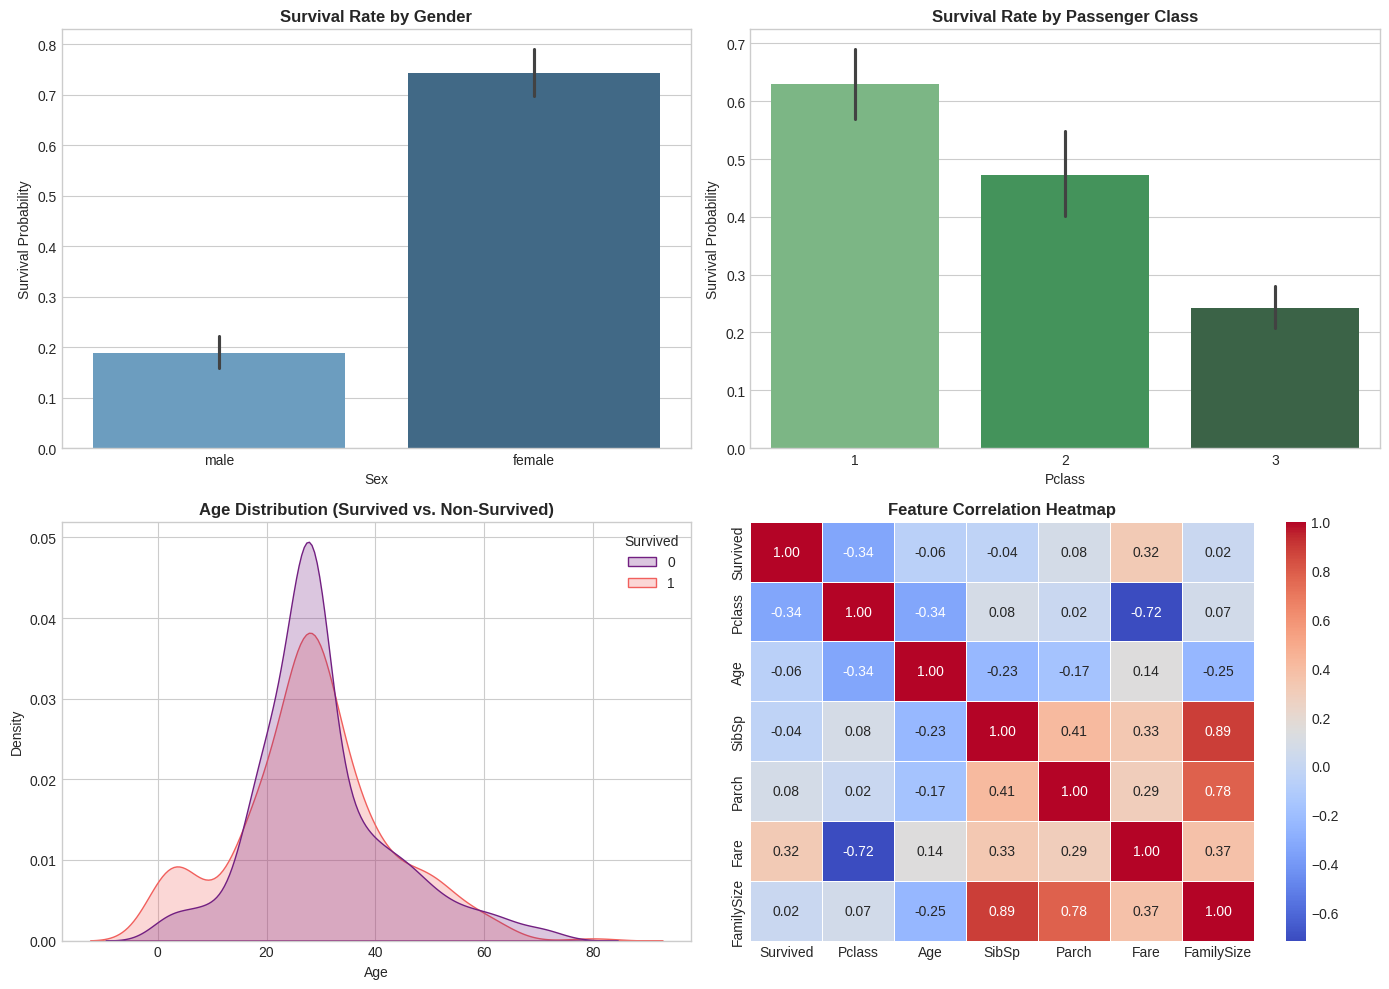

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Ingest Raw Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("--- RAW DATA OVERVIEW ---")
print(f"Shape: {df.shape}")
initial_missing_total = df.isnull().sum().sum()
print(f"Total Missing Values initially: {initial_missing_total}")
print("\nMissing values per column:\n", df.isnull().sum())

# 2. SYSTEMATIC DATA CLEANING & PREPROCESSING
# A. Drop columns with excessive missing data or irrelevant unique identifiers
df_clean = df.drop(columns=["Cabin", "PassengerId", "Ticket"]).copy()

# B. Median Imputation for numerical features with skew/outliers
age_median = df_clean["Age"].median()
df_clean["Age"] = df_clean["Age"].fillna(age_median)

# C. Mode Imputation for categorical features
embarked_mode = df_clean["Embarked"].mode()[0]
df_clean["Embarked"] = df_clean["Embarked"].fillna(embarked_mode)

# D. Outlier Detection & Capping using Interquartile Range (IQR) on 'Fare'
Q1 = df_clean["Fare"].quantile(0.25)
Q3 = df_clean["Fare"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR
df_clean["Fare"] = np.clip(df_clean["Fare"], lower_bound, upper_bound)

# E. Feature Engineering
# Extract titles from names to capture social demographics
df_clean["Title"] = df_clean["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df_clean["Title"] = df_clean["Title"].replace(
    [
        "Lady",
        "Countess",
        "Capt",
        "Col",
        "Don",
        "Dr",
        "Major",
        "Rev",
        "Sir",
        "Jonkheer",
        "Dona",
    ],
    "Rare",
)
df_clean["Title"] = df_clean["Title"].replace("Mlle", "Miss")
df_clean["Title"] = df_clean["Title"].replace("Ms", "Miss")
df_clean["Title"] = df_clean["Title"].replace("Mme", "Mrs")
df_clean.drop(columns=["Name"], inplace=True)

# Family size feature
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1

# F. One-Hot Encoding for categorical variables
df_encoded = pd.get_dummies(
    df_clean, columns=["Sex", "Embarked", "Title"], drop_first=True
)

final_missing_total = df_encoded.isnull().sum().sum()
reduction_rate = (
    (initial_missing_total - final_missing_total) / initial_missing_total
) * 100

print("\n--- POST-PROCESSING OVERVIEW ---")
print(f"Final Shape: {df_encoded.shape}")
print(f"Total Missing Values Remaining: {final_missing_total}")
print(f"Missing Values Reduction: {reduction_rate:.1f}%")

# Save cleaned dataset locally
df_encoded.to_csv("cleaned_data_processed.csv", index=False)
print("Saved preprocessed dataset to 'cleaned_data_processed.csv'")

# 3. EXPLORATORY DATA VISUALIZATION

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Survival Rate by Gender
sns.barplot(ax=axes[0, 0], data=df_clean, x="Sex", y="Survived", palette="Blues_d")
axes[0, 0].set_title("Survival Rate by Gender", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Survival Probability")

# 2. Survival Rate by Passenger Class
sns.barplot(
    ax=axes[0, 1], data=df_clean, x="Pclass", y="Survived", palette="Greens_d"
)
axes[0, 1].set_title(
    "Survival Rate by Passenger Class", fontsize=12, fontweight="bold"
)
axes[0, 1].set_ylabel("Survival Probability")

# 3. Age Distribution by Survival Outcome
sns.kdeplot(
    ax=axes[1, 0],
    data=df_clean,
    x="Age",
    hue="Survived",
    fill=True,
    common_norm=False,
    palette="magma",
)
axes[1, 0].set_title(
    "Age Distribution (Survived vs. Non-Survived)",
    fontsize=12,
    fontweight="bold",
)

# 4. Correlation Heatmap of Numeric Variables
numeric_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
corr = df_clean[numeric_cols].corr()
sns.heatmap(ax=axes[1, 1], data=corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
axes[1, 1].set_title(
    "Feature Correlation Heatmap", fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig("eda_insights.png", dpi=300)
print("Generated and saved visual reports to 'eda_insights.png'")